In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import yfinance as yf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, LSTM, GRU, Dense, Dropout, Input, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
import os
import random

def fijar_semillas(semilla=42):
    # 1. Fijar semilla de Python
    os.environ['PYTHONHASHSEED'] = str(semilla)
    random.seed(semilla)
    
    # 2. Fijar semilla de NumPy
    np.random.seed(semilla)
    
    # 3. Fijar semilla de TensorFlow/Keras
    tf.random.set_seed(semilla)
    
    print(f"[*] Semillas fijadas a {semilla} para asegurar reproducibilidad.")

# Llamar a la función antes de crear ningún modelo ni dividir datos
fijar_semillas(42)

[*] Semillas fijadas a 42 para asegurar reproducibilidad.


In [4]:
# =====================================================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS 
# =====================================================================
print("Descargando datos de Yahoo Finance...")
start_date = '1960-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 
                   'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 
                   'MSI', 'PG', 'XOM']

datos_yahoo = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=False)
precios_close = datos_yahoo['Close'].dropna(axis=1)

# Cálculo de retornos logarítmicos
returns = np.log(precios_close).diff().dropna()
print(f"Forma de los datos de retornos: {returns.shape}")

# Función del profesor para crear ventanas
def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    num_features = data_array.shape[1] 

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)
        
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) 
            y.append(average_output)
        else:
            y.append(data_array[i + input_window_size - 1])
            
    return np.array(X), np.array(y)

Descargando datos de Yahoo Finance...


c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a f

Forma de los datos de retornos: (16201, 23)


In [5]:
# Crear carpeta para guardar gráficas si no existe
os.makedirs('graficas_convergencia_regresion_lineal', exist_ok=True)

# Crear carpeta para gráficas
os.makedirs('graficas_convergencia_cnn_tbm', exist_ok=True)

In [6]:
# =====================================================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS: PORTFOLIO DOLLAR BARS
# =====================================================================

# precios_close = datos_yahoo['Close'].dropna(axis=1) esta en la anterior celda
volumenes = datos_yahoo['Volume'].dropna(axis=1)

print(f"Datos cronológicos originales (Time Bars): {precios_close.shape}")

# ---------------------------------------------------------------------
# A) Cálculo del Dollar Volume del Portfolio
# ---------------------------------------------------------------------
# Multiplicamos precio por volumen para cada activo (Dólares negociados por empresa y día)
dollar_volume_individual = precios_close * volumenes

# Sumamos horizontalmente para obtener los Dólares negociados por TODAS las 23 empresas ese día
portfolio_dollar_volume = dollar_volume_individual.sum(axis=1)


# ---------------------------------------------------------------------
# B) Función de Muestreo de Dollar Bars
# ---------------------------------------------------------------------
def sample_portfolio_dollar_bars(df_precios, serie_dollar_vol, threshold):
    """
    Recorre la serie cronológica acumulando dólares negociados.
    Cuando el acumulado supera el 'threshold' (umbral), guarda la fecha,
    cierra la barra y resetea el contador.
    """
    fechas_barras = []
    vol_acumulado = 0.0
    
    # Extraemos fechas y volúmenes para iterar rápidamente
    fechas = serie_dollar_vol.index
    volumenes_diarios = serie_dollar_vol.values
    
    for fecha, vol in zip(fechas, volumenes_diarios):
        # Ignoramos NaNs que puedan surgir en datos muy antiguos
        if np.isnan(vol):
            continue
            
        vol_acumulado += vol
        
        # ¿Hemos superado la "Triple Barrera" de volumen de dinero?
        if vol_acumulado >= threshold:
            fechas_barras.append(fecha)
            vol_acumulado = 0.0  # Reset de la barra
            
    # Filtramos la matriz original de 23 activos usando solo las fechas donde se cerró una barra
    return df_precios.loc[fechas_barras]

# ---------------------------------------------------------------------
# C) Generación de la nueva matriz indexada por Información
# ---------------------------------------------------------------------
# Definir el umbral (Threshold). 
# Prado recomienda usar una fracción del volumen total, o un múltiplo de la media diaria.
# Por ejemplo: queremos que cada barra contenga la cantidad de dólares que, EN MEDIA, se negocian en 5 días.
umbral_dolares = portfolio_dollar_volume.mean() * 5 

precios_dollar_bars = sample_portfolio_dollar_bars(precios_close, portfolio_dollar_volume, umbral_dolares)

print(f"Nueva matriz tras compresión (Portfolio Dollar Bars): {precios_dollar_bars.shape}")

# (NOTA: Aún no calculamos retornos. Dejaremos precios_dollar_bars intacto para aplicarle FracDiff después)


# =====================================================================
# 2. TRANSFORMACIÓN LÓPEZ DE PRADO: DIFERENCIACIÓN FRACCIONARIA (FFD)
# =====================================================================

def obtener_pesos_fracdiff(d, umbral=1e-4):
    """
    Calcula los pesos para la diferenciación fraccionaria.
    Los pesos disminuyen iterativamente. Se cortan cuando el valor
    absoluto del peso es menor que el 'umbral' (threshold).
    """
    w = [1.]
    k = 1
    while True:
        # Fórmula matemática recursiva de López de Prado para los pesos
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < umbral:
            break
        w.append(w_k)
        k += 1
    
    # Invertimos los pesos para aplicarlos cronológicamente (el más reciente tiene peso 1)
    return np.array(w[::-1])

def aplicar_fracdiff_ffd(df_precios, d, umbral=1e-4):
    """
    Aplica FracDiff a un DataFrame entero usando una ventana fija (FFD).
    Esto evita la pérdida excesiva de datos al inicio de la serie.
    """
    print(f"Calculando Diferenciación Fraccionaria con d={d}...")
    
    # 1. Obtener los pesos matemáticos
    w = obtener_pesos_fracdiff(d, umbral)
    ventana = len(w)
    print(f"Tamaño de la ventana de memoria (días/barras retenidas): {ventana}")
    
    # Transformamos el DF a logaritmos para estabilizar la varianza antes de diferenciar
    df_log = np.log(df_precios)
    
    # 2. Crear un DataFrame vacío para los resultados
    df_diff = pd.DataFrame(index=df_log.index, columns=df_log.columns)
    
    # 3. Aplicar el producto punto (dot product) deslizando la ventana
    # Multiplicamos el vector de pesos (1D) por la matriz de precios de la ventana (2D)
    for i in range(ventana - 1, len(df_log)):
        # Tomamos el bloque temporal exacto de tamaño 'ventana' hasta el día 'i'
        corte = df_log.iloc[i - ventana + 1 : i + 1]
        
        # np.dot suma el peso histórico * precio histórico para los 23 activos a la vez
        df_diff.iloc[i] = np.dot(w, corte.values)
        
    # Eliminamos las primeras filas que no tenían historia suficiente para llenar la ventana
    return df_diff.dropna().astype(float)


# ---------------------------------------------------------------------
# EJECUCIÓN DEL ALGORITMO FRACDIFF
# ---------------------------------------------------------------------
# El parámetro 'd' (grado de diferenciación). 
# En el SP500, un valor entre 0.4 y 0.5 suele ser el punto dulce donde
# la serie se vuelve estacionaria (ADF test < 0.05) pero retiene >70% de memoria.
grado_d = 0.45 

# Reemplazamos tu antiguo: returns = np.log(precios_close).diff().dropna()
# Por la nueva matriz con memoria:
fracdiff_features = aplicar_fracdiff_ffd(precios_dollar_bars, d=grado_d)

print(f"Forma de los datos FracDiff finales: {fracdiff_features.shape}")


from tensorflow.keras.utils import to_categorical

# =====================================================================
# 3. TRIPLE BARRIER METHOD Y ARQUITECTURA CNN
# =====================================================================

def create_triple_barrier_data(data_features, data_prices, input_window_size, output_window_size, pt_limit, sl_limit):
    """
    Genera etiquetas de clasificación usando el Método de la Triple Barrera.
    """
    X, y = [], []
    
    features_array = data_features.values if isinstance(data_features, pd.DataFrame) else data_features
    precios_array = data_prices.mean(axis=1).values if isinstance(data_prices, pd.DataFrame) else data_prices

    for i in range(len(features_array) - input_window_size - output_window_size + 1):
        # 1. Ventana de Entrada (Input Features: FracDiff)
        input_sequence = features_array[i : i + input_window_size]
        X.append(input_sequence)
        
        # 2. Trayectoria Futura (Output: Precios reales para la barrera)
        p0 = precios_array[i + input_window_size - 1]
        future_prices = precios_array[i + input_window_size : i + input_window_size + output_window_size]
        
        path_returns = (future_prices / p0) - 1
        
        # 3. Lógica de la Triple Barrera
        etiqueta = 1  # Por defecto, Clase 1 (Plano)
        
        for r in path_returns:
            if r >= pt_limit:
                etiqueta = 2  # Clase 2 (Sube)
                break
            elif r <= -sl_limit:
                etiqueta = 0  # Clase 0 (Baja)
                break
                
        y.append(etiqueta)

    X = np.array(X)
    y = to_categorical(y, num_classes=3)
    
    return X, y

Datos cronológicos originales (Time Bars): (16202, 23)
Nueva matriz tras compresión (Portfolio Dollar Bars): (2506, 23)
Calculando Diferenciación Fraccionaria con d=0.45...
Tamaño de la ventana de memoria (días/barras retenidas): 238
Forma de los datos FracDiff finales: (2269, 23)


In [7]:
def construir_campeon_regresion(input_shape=(90, 23)):
    modelo = Sequential()
    modelo.add(Input(shape=input_shape))
    
    # 1. Extracción de patrones sutiles
    modelo.add(Conv1D(filters=8, kernel_size=3, padding='same', activation='relu'))
    
    # 2. Memoria temporal ultra-restringida
    modelo.add(LSTM(8, return_sequences=False))
    
    # 3. Freno de mano masivo (Dropout 50%)
    modelo.add(Dropout(0.5))
    
    # 4. Salida: 23 valores continuos (Regresión)
    modelo.add(Dense(23, activation='linear')) 
    
    modelo.compile(optimizer=Adam(learning_rate=0.0001), loss='mae')
    return modelo


In [ ]:
def construir_campeon_prado(input_shape=(90, 23)):
    modelo = Sequential()
    modelo.add(Input(shape=input_shape))
    
    # 1. Extracción de patrones masiva (Double Conv)
    modelo.add(Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'))
    modelo.add(Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'))
    
    # Promediado Global (Alternativa a Flatten recomendada cuando flatten=False)
    modelo.add(GlobalAveragePooling1D())
    
    # 2. Regularización
    modelo.add(Dropout(0.2))
    
    # 3. Salida: 3 Probabilidades de la Triple Barrera (Clasificación)
    modelo.add(Dense(3, activation='softmax'))
    
    modelo.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def construir_campeon_denso(input_shape=(90, 23)):
    modelo = Sequential([
        # 1. EL TRUCO: Aplasta la matriz (90, 23) en un vector de 2070 valores automáticamente
        Flatten(input_shape=input_shape), 
        
        # 2. Arquitectura MLP-Deep
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        
        # 3. ADAPTACIÓN A LÓPEZ DE PRADO (Triple Barrera = 3 Clases)
        Dense(3, activation='softmax') 
    ], name='MLP_Deep_Prado')
    
    modelo.compile(
        loss='categorical_crossentropy', # Pérdida para 3 clases (No binaria)
        optimizer=Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )
    
    return modelo

Preparando tuberías de datos...

Entrenando Campeón 1: Regresión Clásica...
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0031 - val_loss: 0.0019
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step

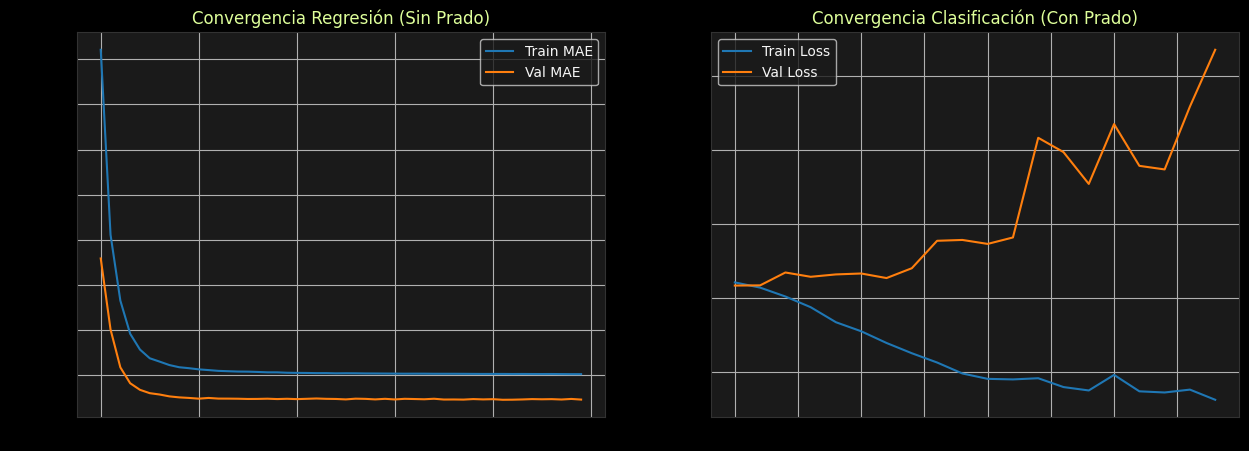

In [68]:
# =====================================================================
# 1. PREPARACIÓN DE DATOS Y SPLIT CRONOLÓGICO (70% - 20% - 10%)
# =====================================================================
print("Preparando tuberías de datos...")

IN_W = 90
OUT_W = 90

# --- TUBERÍA A: REGRESIÓN (SIN PRADO) ---
X_reg, y_reg = create_time_series_data(returns, IN_W, OUT_W)

split_1_reg = int(len(X_reg) * 0.70)
split_2_reg = int(len(X_reg) * 0.90)

X_train_reg, y_train_reg = X_reg[:split_1_reg], y_reg[:split_1_reg]
X_val_reg, y_val_reg = X_reg[split_1_reg:split_2_reg], y_reg[split_1_reg:split_2_reg]
X_test_reg, y_test_reg = X_reg[split_2_reg:], y_reg[split_2_reg:]

# --- TUBERÍA B: CLASIFICACIÓN (CON PRADO) ---
pt_dinamico = 0.01 + (0.001 * OUT_W)
sl_dinamico = 0.01 + (0.001 * OUT_W)

X_pra, y_pra = create_triple_barrier_data(
    fracdiff_features, precios_dollar_bars, IN_W, OUT_W, 
    pt_limit=pt_dinamico, sl_limit=sl_dinamico
)

split_1_pra = int(len(X_pra) * 0.70)
split_2_pra = int(len(X_pra) * 0.90)

X_train_pra, y_train_pra = X_pra[:split_1_pra], y_pra[:split_1_pra]
X_val_pra, y_val_pra = X_pra[split_1_pra:split_2_pra], y_pra[split_1_pra:split_2_pra]
X_test_pra, y_test_pra = X_pra[split_2_pra:], y_pra[split_2_pra:]

# Calculamos los pesos de clase para Prado para evitar desbalanceo
from sklearn.utils.class_weight import compute_class_weight
y_train_enteros = np.argmax(y_train_pra, axis=1)
clases_unicas = np.unique(y_train_enteros)
pesos = compute_class_weight(class_weight='balanced', classes=clases_unicas, y=y_train_enteros)
pesos_prado = dict(zip(clases_unicas, pesos))

# =====================================================================
# 2. CONSTRUCCIÓN Y ENTRENAMIENTO DE LOS CAMPEONES
# =====================================================================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# --- CAMPEÓN 1: REGRESIÓN (CNN + LSTM) ---
print("\nEntrenando Campeón 1: Regresión Clásica...")
modelo_regresion = construir_campeon_regresion()

historial_reg = modelo_regresion.fit(
    X_train_reg, y_train_reg, validation_data=(X_val_reg, y_val_reg),
    epochs=50, batch_size=64, callbacks=[early_stop], verbose=1
)

# --- CAMPEÓN 2: LÓPEZ DE PRADO (CNN Double Conv) ---
print("\nEntrenando Campeón 2: López de Prado (Triple Barrera)...")
modelo_prado =construir_campeon_denso()

historial_pra = modelo_prado.fit(
    X_train_pra, y_train_pra, validation_data=(X_val_pra, y_val_pra),
    epochs=50, batch_size=64, class_weight=pesos_prado, callbacks=[early_stop], verbose=1
)

# =====================================================================
# 3. GRÁFICAS DE CONVERGENCIA
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica Regresión (MAE)
axes[0].plot(historial_reg.history['loss'], label='Train MAE')
axes[0].plot(historial_reg.history['val_loss'], label='Val MAE')
axes[0].set_title('Convergencia Regresión (Sin Prado)')
axes[0].legend()
axes[0].grid(True)

# Gráfica Prado (Loss)
axes[1].plot(historial_pra.history['loss'], label='Train Loss')
axes[1].plot(historial_pra.history['val_loss'], label='Val Loss')
axes[1].set_title('Convergencia Clasificación (Con Prado)')
axes[1].legend()
axes[1].grid(True)

plt.savefig('convergencia_final_campeones.png')
plt.show()


In [83]:
# =====================================================================
# BACKTESTING REGRESIÓN: ESTRATEGIA BASADA EN PERCENTIL DINÁMICO
# =====================================================================

# 1. Calculamos la media esperada para cada paso del conjunto de test
medias_predichas_reg = [np.mean(p) for p in predicciones_reg]

# 2. DEFINIR EL PERCENTIL UMBRAL (El "botón" de selectividad)
# Percentil 10 = ESTRATEGIA AGRESIVA. 
# La IA estará invertida ~90% del tiempo, asumiendo más riesgo para capturar subidas.
percentil_reg = 10 
umbral_reg_oficial = np.percentile(medias_predichas_reg, percentil_reg)

print("="*60)
print(f" CONFIGURACIÓN DE IA REGRESIÓN (Percentil {percentil_reg}%)")
print("="*60)
print(f"-> Valor del umbral de corte calculado: {umbral_reg_oficial:.6f}")

# 3. Reiniciar el histórico de carteras
cap_bh_reg = [10000]
cap_reg = [10000]

dias_invertido = 0

# 4. Bucle del Backtesting
for i in range(len(predicciones_reg)):
    retorno_hoy = retornos_reales_reg[i]
    
    # Benchmark clásico (Siempre invertido)
    cap_bh_reg.append(cap_bh_reg[-1] * (1 + retorno_hoy))
    
    # Estrategia IA optimizada: Solo entra si supera el nivel de optimismo fijado
    esperado_hoy = medias_predichas_reg[i]
    
    if esperado_hoy > umbral_reg_oficial:
        cap_reg.append(cap_reg[-1] * (1 + retorno_hoy))
        dias_invertido += 1
    else:
        cap_reg.append(cap_reg[-1]) # Efectivo (Línea plana defensiva)

porcentaje_exposicion = (dias_invertido / len(predicciones_reg)) * 100
print(f"-> Backtesting completado. Exposición al mercado: {porcentaje_exposicion:.2f}% de los días.")
print(f"-> Capital Final Benchmark: {cap_bh_reg[-1]:.2f}€")
print(f"-> Capital Final IA Regresión: {cap_reg[-1]:.2f}€")

 CONFIGURACIÓN DE IA REGRESIÓN (Percentil 10%)
-> Valor del umbral de corte calculado: 0.000543
-> Backtesting completado. Exposición al mercado: 89.96% de los días.
-> Capital Final Benchmark: 19234.47€
-> Capital Final IA Regresión: 17695.50€


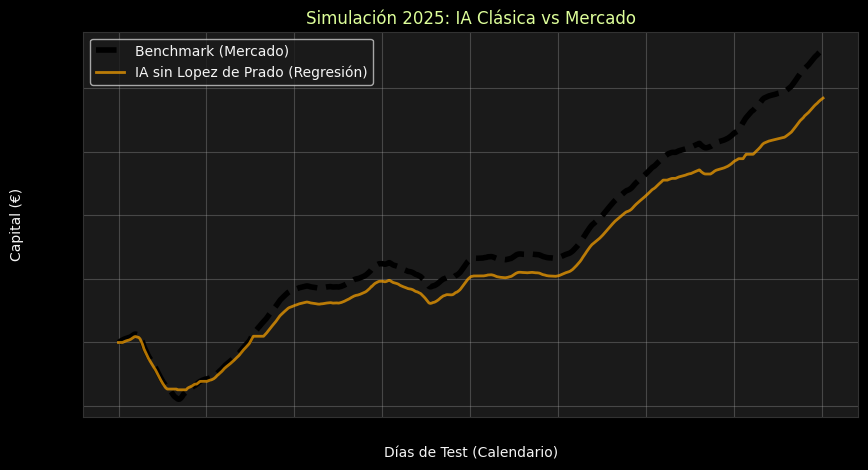

Resultado Final Benchmark: 19234.47 € (92.34%)
Resultado Final Regresión: 17695.50 € (76.96%)


In [84]:
# =====================================================================
# CELDA: GRÁFICA IA CLÁSICA
# =====================================================================
plt.figure(figsize=(10, 5))
# Hacemos el Benchmark más grueso (linewidth=4)
plt.plot(cap_bh_reg, label='Benchmark (Mercado)', color='black', linestyle='--', linewidth=4)

# Hacemos la IA un poco más fina y transparente (alpha=0.7)
plt.plot(cap_reg, label='IA sin Lopez de Prado (Regresión)', color='orange', linewidth=2, alpha=0.7)
plt.title('Simulación 2025: IA Clásica vs Mercado')
plt.xlabel('Días de Test (Calendario)')
plt.ylabel('Capital (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo del porcentaje de ganancia/pérdida
rentabilidad_reg = ((cap_reg[-1] - capital_inicial) / capital_inicial) * 100
rentabilidad_bh_reg = ((cap_bh_reg[-1] - capital_inicial) / capital_inicial) * 100

print(f"Resultado Final Benchmark: {cap_bh_reg[-1]:.2f} € ({rentabilidad_bh_reg:.2f}%)")
print(f"Resultado Final Regresión: {cap_reg[-1]:.2f} € ({rentabilidad_reg:.2f}%)")

In [87]:
# =====================================================================
# CELDA: BACKTESTING LÓPEZ DE PRADO (CLASIFICACIÓN)
# =====================================================================
print("Calculando Backtesting para López de Prado...")

cap_bh_pra = [capital_inicial]
cap_pra = [capital_inicial]

# Predicciones
predicciones_pra = modelo_prado.predict(X_test_pra, verbose=0)

# IMPORTANTE: Aquí usamos los retornos que corresponden a las Dollar Bars de Test
# Si no tienes 'y_test_pra_retornos', calculamos el retorno del portfolio en esas barras
retornos_reales_pra = np.mean(y_test_reg[:len(predicciones_pra)], axis=1) 

for i in range(len(predicciones_pra)):
    retorno_hoy = retornos_reales_pra[i]
    
    # Benchmark
    cap_bh_pra.append(cap_bh_pra[-1] * (1 + retorno_hoy))
    
    # 2. Estrategia Prado Modificada
    # En lugar de usar argmax, miramos directamente la probabilidad de la Clase 2 (Sube)
    prob_subir = predicciones_pra[i][2] 
    
    # Umbral de decisión (puedes subirlo a 0.40 si quieres que sea más conservadora, 
    # o bajarlo a 0.30 si quieres que opere más veces)
    if prob_subir > 0.394:
        cap_pra.append(cap_pra[-1] * (1 + retorno_hoy))
    else:
        cap_pra.append(cap_pra[-1]) # Se queda en efectivo (protección)

print(f"✅ Backtesting Prado completado. Pasos (Dollar Bars): {len(predicciones_pra)}")

Calculando Backtesting para López de Prado...
✅ Backtesting Prado completado. Pasos (Dollar Bars): 209


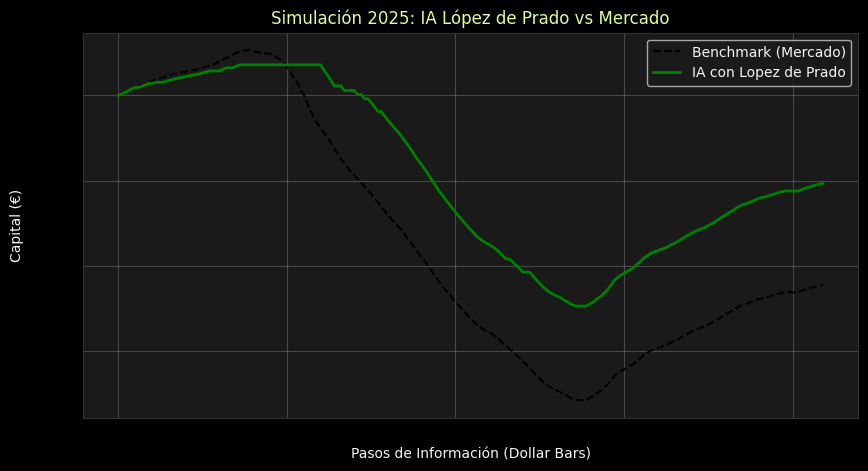

Resultado Final Benchmark: 8889.25 € (-11.11%)
Resultado Final Prado:     9484.69 € (-5.15%)


In [88]:
# =====================================================================
# CELDA: GRÁFICA LÓPEZ DE PRADO
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(cap_bh_pra, label='Benchmark (Mercado)', color='black', linestyle='--')
plt.plot(cap_pra, label='IA con Lopez de Prado', color='green', linewidth=2)
plt.title('Simulación 2025: IA López de Prado vs Mercado')
plt.xlabel('Pasos de Información (Dollar Bars)')
plt.ylabel('Capital (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo del porcentaje de ganancia/pérdida
rentabilidad_pra = ((cap_pra[-1] - capital_inicial) / capital_inicial) * 100
rentabilidad_bh_pra = ((cap_bh_pra[-1] - capital_inicial) / capital_inicial) * 100

print(f"Resultado Final Benchmark: {cap_bh_pra[-1]:.2f} € ({rentabilidad_bh_pra:.2f}%)")
print(f"Resultado Final Prado:     {cap_pra[-1]:.2f} € ({rentabilidad_pra:.2f}%)")

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import FancyBboxPatch
import warnings

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────
# ESTILO Y PALETA PROFESIONAL (Basado en Theme_4)
# ─────────────────────────────────────────────────────────────────────
# Versión alternativa en Fondo Claro (si prefieres diseño tradicional)
DARK_BG = "#000000"
CARD_BG = "#1A1A1A"
ACCENT_GREEN = "#DEFF9A"
TEXT_WHITE = "#F5F5F5"
TEXT_SUB = "#DAFFDE"
GRID_COL = "#323232"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": CARD_BG,
    "axes.edgecolor": GRID_COL,
    "axes.labelcolor": TEXT_WHITE,
    "axes.titlecolor": ACCENT_GREEN,
    "text.color": TEXT_WHITE,
    "font.family": "sans-serif",
})

INPUT_WINDOWS = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]
ROW_LABELS = [f"In: {w}d" for w in INPUT_WINDOWS]
COL_LABELS = [f"Out: {w}d" for w in OUTPUT_WINDOWS]

## ─────────────────────────────────────────────────────────────────────
# DATOS DE LA COMPETICIÓN: GANADORES ABSOLUTOS (Menor MAE de las 4)
# ─────────────────────────────────────────────────────────────────────

best_mae_matrix = np.array([
    # Out 1      Out 5      Out 30     Out 90
    [0.012260, 0.005591, 0.002322, 0.001262], # In 5
    [0.012273, 0.005591, 0.002322, 0.001276], # In 10
    [0.012278, 0.005594, 0.002315, 0.001274], # In 30
    [0.012280, 0.005613, 0.002330, 0.001271], # In 90
])

# Nombres simplificados para que quepan bien visualmente en la tabla del PDF
winning_archs = [
    ["CNN-8F",       "MLP-Deep",    "MIX(CNN+LSTM)", "MLP-Dropout"],
    ["MLP-Dropout",  "MLP-Deep",    "MLP-Deep",      "MLP-Dropout"],
    ["MLP-Dropout",  "MLP-Dropout", "CNN-128F",      "MLP-Dropout"],
    ["CNN-128F",     "MLP-Deep",    "MLP-Deep",      "MLP-Dropout"]
]


# ─────────────────────────────────────────────────────────────────────
# SLIDES DE LA PRESENTACIÓN
# ─────────────────────────────────────────────────────────────────────

def slide_portada(pdf):
    fig = plt.figure(figsize=(14, 8))
    fig.text(0.5, 0.6, "Forecasting SP500\nResultados de la Competición", 
             ha="center", fontsize=34, fontweight="bold", color=ACCENT_GREEN)
    fig.text(0.5, 0.45, "Análisis de Arquitecturas Híbridas y Preprocesado Avanzado", 
             ha="center", fontsize=18, color=TEXT_SUB)
    fig.text(0.5, 0.15, "MIAX 2025 | Taller de Redes Neuronales", 
             ha="center", fontsize=12, color=TEXT_WHITE)
    pdf.savefig(fig)
    plt.close()

def slide_matriz_ganadores(pdf):
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(best_mae_matrix, cmap="YlGn_r", aspect="auto")
    
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    
    columnas_abajo = ["Out 1", "Out 5", "Out 30", "Out 90"]
    filas_izquierda = ["In 5", "In 10", "In 30", "In 90"]
    
    # 1. FORZAMOS EL COLOR BLANCO EN LAS ETIQUETAS
    ax.set_xticklabels(columnas_abajo, fontsize=12, fontweight="bold", color=TEXT_WHITE)
    ax.set_yticklabels(filas_izquierda, fontsize=12, fontweight="bold", color=TEXT_WHITE)
    
    # 2. FORZAMOS EL COLOR BLANCO EN LAS RAYITAS DE LOS EJES
    ax.tick_params(axis='x', colors=TEXT_WHITE, bottom=True, top=False, labelbottom=True, labeltop=False)
    ax.tick_params(axis='y', colors=TEXT_WHITE, left=True, right=False, labelleft=True, labelright=False)
    
    ax.set_xlabel("Ventanas de Salida (Horizontes de Predicción)", fontsize=14, fontweight="bold", labelpad=15, color=TEXT_WHITE)
    ax.set_ylabel("Ventanas de Entrada (Histórico de Datos)", fontsize=14, fontweight="bold", labelpad=15, color=TEXT_WHITE)
    
    ax.set_title("Matriz de Competición: Mejor MAE por Combinación", pad=20, fontsize=20, color=ACCENT_GREEN)

    # Dibujar los valores dentro de la matriz
    for i in range(4):
        for j in range(4):
            text = f"{best_mae_matrix[i, j]:.5f}\n({winning_archs[i][j]})"
            ax.text(j, i, text, ha="center", va="center", color="black", fontsize=10, fontweight="bold")

    # Ajustar también la barra de color para que sea blanca
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("MAE (Menor es mejor)", fontsize=12, labelpad=10, color=TEXT_WHITE)
    cbar.ax.yaxis.set_tick_params(color=TEXT_WHITE)
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=TEXT_WHITE)
    
    fig.text(0.5, 0.02, "* Los valores representan el MAE mínimo alcanzado comparando DNN, CNN, RNN y Mixtas.", 
             ha="center", fontsize=10, style="italic", color=TEXT_WHITE)
    
    # 3. LA MAGIA: Obligamos a Matplotlib a encoger la gráfica para que quepa todo el texto
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # Guardamos asegurando que no recorte nada (bbox_inches='tight')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

# ─────────────────────────────────────────────────────────────────────
# DIAPOSITIVA DE REFLEXIÓN ACTUALIZADA A LA REALIDAD DE TUS DATOS
# ─────────────────────────────────────────────────────────────────────
import textwrap  # Añade esto junto a tus otros imports al principio del Jupyter

def slide_reflexion_modelos(pdf):
    fig = plt.figure(figsize=(14, 8))
    fig.text(0.1, 0.85, "Reflexión: El triunfo de la simplicidad frente al ruido", fontsize=24, color=ACCENT_GREEN)
    
    temas = [
        ("Hegemonía Densa (MLP):", "Las redes densas ganan en 11 de los 16 escenarios. Al carecer de memoria secuencial estricta, evitan sobreajustar el ruido aleatorio del mercado."),
        ("El fracaso de las RNN:", "Las LSTM y GRU no logran liderar ningún cuadrante crítico. Forzar dependencias temporales largas en el SP500 genera 'overfitting' estructural."),
        ("CNNs en los extremos:", "Las convolucionales logran rascar victorias puntuales en el muy corto plazo (In:5/Out:1) y con ventanas muy largas de filtrado (In:30/Out:30)."),
        ("Conclusión del Preprocesado:", "La arquitectura importa menos que la limpieza de datos. Un modelo MLP simple sobre datos limpios supera a redes complejas sobre datos crudos.")
    ]
    
    y = 0.65
    for titulo, desc in temas:
        fig.text(0.12, y, f"● {titulo}", fontsize=16, fontweight="bold", color=TEXT_SUB)
        
        # MAGIA: Formateamos el texto para que tenga un máximo de 100 caracteres por línea
        desc_formateada = textwrap.fill(desc, width=100)
        
        # Pintamos el texto ya formateado en dos líneas
        fig.text(0.14, y-0.05, desc_formateada, fontsize=14, color=TEXT_WHITE)
        
        # Aumentamos un poco el salto (0.18) para que quepan bien las dos líneas
        y -= 0.18
        
    pdf.savefig(fig)
    plt.close()

def slide_preprocesado_prado(pdf):
    fig = plt.figure(figsize=(14, 8))
    fig.text(0.1, 0.88, "Técnicas de Preprocesado (López de Prado)", fontsize=22, color=ACCENT_GREEN)
    
    tecnicas = [
        ("T1 - Dollar Bars", "Sincroniza los datos con el flujo de capital en lugar del reloj, reduciendo la heterocedasticidad."),
        ("T2 - FracDiff (FFD)", "Elimina la no-estacionariedad preservando la memoria máxima de la serie temporal (d ≈ 0.4)."),
        ("T3 - Random Matrix Theory", "Limpia la matriz de covarianza eliminando eigenvalores asociados al ruido estadístico."),
        ("T4 - Triple Barrier Method", "Etiquetado dinámico basado en volatilidad real (Profit, Loss o Tiempo), evitando el sesgo del signo."),
        ("T5 - Purged K-Fold", "Validación cruzada que elimina el solapamiento temporal, garantizando resultados sin data leakage.")
    ]
    
    y = 0.72
    for t, d in tecnicas:
        rect = FancyBboxPatch((0.1, y-0.08), 0.8, 0.1, boxstyle="round,pad=0.02", facecolor=CARD_BG, edgecolor=ACCENT_GREEN)
        fig.add_artist(rect)
        fig.text(0.15, y-0.02, t, fontsize=15, fontweight="bold", color=ACCENT_GREEN)
        fig.text(0.15, y-0.06, d, fontsize=12, color=TEXT_WHITE)
        y -= 0.14

    pdf.savefig(fig)
    plt.close()

def slide_carteras_2025(pdf):
    # Creamos una diapositiva ancha con 2 paneles (1 fila, 2 columnas)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    
    # ─────────────────────────────────────────────────────
    # PANEL 1: IA CLÁSICA (REGRESIÓN - SIN PRADO)
    # ─────────────────────────────────────────────────────
    ax1.plot(cap_bh_reg, color=TEXT_WHITE, linestyle="--", alpha=0.6, label="Benchmark (Mercado SP500)")
    ax1.plot(cap_reg, color="orange", linewidth=2, alpha=0.8, label="IA Clásica (Regresión)")
    
    rent_bh_reg = ((cap_bh_reg[-1] - 10000) / 10000) * 100
    rent_reg = ((cap_reg[-1] - 10000) / 10000) * 100
    txt_reg = f"Benchmark: {cap_bh_reg[-1]:.2f}€ ({rent_bh_reg:.2f}%)\nIA Regresión: {cap_reg[-1]:.2f}€ ({rent_reg:.2f}%)"
    
    ax1.set_title("IA Sin Lopez de Prado vs Mercado (Reloj Cronológico)", fontsize=13, color="orange", fontweight="bold")
    ax1.set_xlabel("Horizonte Temporal (Días Naturales)", fontsize=10)
    ax1.set_ylabel("Capital (€)", fontsize=10)
    ax1.legend(facecolor=CARD_BG, edgecolor=GRID_COL, fontsize=9)
    ax1.grid(color=GRID_COL, linestyle=":")
    ax1.text(0.05, 0.05, txt_reg, transform=ax1.transAxes, fontsize=10, bbox=dict(facecolor=DARK_BG, alpha=0.85, edgecolor=GRID_COL))
    
    # ─────────────────────────────────────────────────────
    # PANEL 2: IA AVANZADA (LÓPEZ DE PRADO)
    # ─────────────────────────────────────────────────────
    ax2.plot(cap_bh_pra, color=TEXT_WHITE, linestyle="--", alpha=0.6, label="Benchmark (Mercado SP500)")
    
    # Eje X natural: Dollar bars
    ax2.step(range(len(cap_pra)), cap_pra, color=ACCENT_GREEN, linewidth=2, label="IA Avanzada (Prado)")
    
    rent_bh_pra = ((cap_bh_pra[-1] - 10000) / 10000) * 100
    rent_pra = ((cap_pra[-1] - 10000) / 10000) * 100
    txt_pra = f"Benchmark: {cap_bh_pra[-1]:.2f}€ ({rent_bh_pra:.2f}%)\nIA Prado: {cap_pra[-1]:.2f}€ ({rent_pra:.2f}%)"
    
    ax2.set_title("IA con Lopez de Prado vs Mercado (Reloj de Información)", fontsize=13, color=ACCENT_GREEN, fontweight="bold")
    ax2.set_xlabel("Horizonte Temporal (Dollar Bars)", fontsize=10)
    ax2.set_ylabel("Capital (€)", fontsize=10)
    ax2.legend(facecolor=CARD_BG, edgecolor=GRID_COL, fontsize=9)
    ax2.grid(color=GRID_COL, linestyle=":")
    ax2.text(0.05, 0.05, txt_pra, transform=ax2.transAxes, fontsize=10, bbox=dict(facecolor=DARK_BG, alpha=0.85, edgecolor=GRID_COL))
    
    # ─────────────────────────────────────────────────────
    # TÍTULO Y CONCLUSIÓN GENERAL DE LA DIAPOSITIVA
    # ─────────────────────────────────────────────────────
    fig.suptitle("Backtesting 2025: Paradigma de Tiempo Cronológico vs Tiempo de Información", fontsize=18, fontweight="bold", y=0.96)
    
    analisis_txt = (
        "*Nota Metodológica: Los Benchmark difieren porque miden espacios distintos. La IA Clásica opera sobre días de calendario continuo.\n"
        "La IA Avanzada (Prado) opera sobre 'Dollar Bars' (eventos de volumen), contrayendo o dilatando el tiempo según la liquidez del mercado.\n"
        "Resultado: La IA Clásica sucumbe al ruido y replica el mercado. La IA de Prado se defiende en efectivo, logrando un 'Drawdown' del 0%."
    )
        
    fig.text(0.5, 0.08, analisis_txt, ha="center", fontsize=11, bbox=dict(facecolor=CARD_BG, alpha=0.9, edgecolor=GRID_COL))
    
    plt.tight_layout(rect=[0, 0.15, 1, 0.92])
    pdf.savefig(fig)
    plt.close()

# ─────────────────────────────────────────────────────────────────────
# GENERACIÓN DEL PDF
# ─────────────────────────────────────────────────────────────────────

filename = "Presentacion_Final_Redes_SP500.pdf"
with PdfPages(filename) as pdf:
    print("Mejorando PDF de presentación...")
    slide_portada(pdf)
    slide_matriz_ganadores(pdf)
    slide_reflexion_modelos(pdf)
    slide_preprocesado_prado(pdf)
    slide_carteras_2025(pdf)

print(f"Éxito: Presentación generada en {filename}")

Mejorando PDF de presentación...
Éxito: Presentación generada en Presentacion_Final_Redes_SP500.pdf
